In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [2]:
import numpy as np
import pandas as pd
import os
import kagglehub

In [3]:
!pip install --upgrade scikit-learn imbalanced-learn hmmlearn xgboost

import os
import kagglehub
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    confusion_matrix, classification_report,
    roc_curve, auc, precision_recall_curve,
    f1_score, precision_score, recall_score,
    ConfusionMatrixDisplay
)
from hmmlearn import hmm
import xgboost as xgb

import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')

print("All libraries imported successfully.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 75.7 MB/s eta 0:00:00:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 166.0/166.0 kB 10.4 MB/s eta 0:00:00
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.6.1
    Uninstalling scikit-learn-1.6.1:
      Successfully uninstalled scikit-learn-1.6.1
All libraries imported successfully.


In [4]:
dataset_dir    = kagglehub.dataset_download("kartik2112/fraud-detection")
full_file_path = os.path.join(dataset_dir, 'fraudTrain.csv')

df_raw = pd.read_csv(full_file_path)
df     = df_raw.copy()

print(f"Dataset loaded.  Shape: {df.shape}")
print(f"Rows: {df.shape[0]:,}   Columns: {df.shape[1]}")

Dataset loaded.  Shape: (1296675, 23)
Rows: 1,296,675   Columns: 23


In [5]:
print("=" * 60)
print("STEP 1 — BASIC STRUCTURE")
print("=" * 60)

print("\n--- Column names & dtypes ---")
print(df.dtypes)

print("\n--- First 5 rows ---")
print(df.head())

print("\n--- Statistical summary (numeric columns) ---")
print(df.describe().T.to_string())

print("\n--- Statistical summary (object columns) ---")
print(df.describe(include='object').T.to_string())

print("\n--- Dataset context ---")
print(f"Time span        : {df['trans_date_trans_time'].min()}  →  {df['trans_date_trans_time'].max()}")
print(f"Unique cards     : {df['cc_num'].nunique():,}")
print(f"Unique merchants : {df['merchant'].nunique():,}")
print(f"Categories       : {sorted(df['category'].unique())}")
print(f"Gender values    : {df['gender'].unique()}")

STEP 1 — BASIC STRUCTURE

--- Column names & dtypes ---
Unnamed: 0                 int64
trans_date_trans_time     object
cc_num                     int64
merchant                  object
category                  object
amt                      float64
first                     object
last                      object
gender                    object
street                    object
city                      object
state                     object
zip                        int64
lat                      float64
long                     float64
city_pop                   int64
job                       object
dob                       object
trans_num                 object
unix_time                  int64
merch_lat                float64
merch_long               float64
is_fraud                   int64
dtype: object

--- First 5 rows ---
   Unnamed: 0 trans_date_trans_time            cc_num  \
0           0   2019-01-01 00:00:18  2703186189652095   
1           1   2019-01-01 00:00:44

In [6]:
print("=" * 60)
print("STEP 2 — DATA QUALITY CHECKS")
print("=" * 60)

# Missing values
missing     = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df  = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_df  = missing_df[missing_df['Missing Count'] > 0]

if missing_df.empty:
    print("\n✓ No missing values found.")
else:
    print("\n✗ Missing values detected:")
    print(missing_df)

# Duplicates
n_dup = df.duplicated().sum()
print(f"\n{'✓' if n_dup == 0 else '✗'} Duplicate rows: {n_dup:,}")

# Constant columns
const_cols = [c for c in df.columns if df[c].nunique() == 1]
print(f"\n{'✓' if not const_cols else '✗'} Constant columns: {const_cols if const_cols else 'None'}")

# Cardinality
print("\n--- Unique value counts per column ---")
for col in df.columns:
    print(f"  {col:<30} {df[col].nunique():>8,} unique values")

STEP 2 — DATA QUALITY CHECKS

✓ No missing values found.

✓ Duplicate rows: 0

✓ Constant columns: None

--- Unique value counts per column ---
  Unnamed: 0                     1,296,675 unique values
  trans_date_trans_time          1,274,791 unique values
  cc_num                              983 unique values
  merchant                            693 unique values
  category                             14 unique values
  amt                              52,928 unique values
  first                               352 unique values
  last                                481 unique values
  gender                                2 unique values
  street                              983 unique values
  city                                894 unique values
  state                                51 unique values
  zip                                 970 unique values
  lat                                 968 unique values
  long                                969 unique values
  city_pop    

STEP 3 — TARGET VARIABLE (CLASS IMBALANCE)

Legitimate transactions : 1,289,169  (99.421%)
Fraudulent transactions :    7,506  (0.579%)
Imbalance ratio         : 171.8 : 1


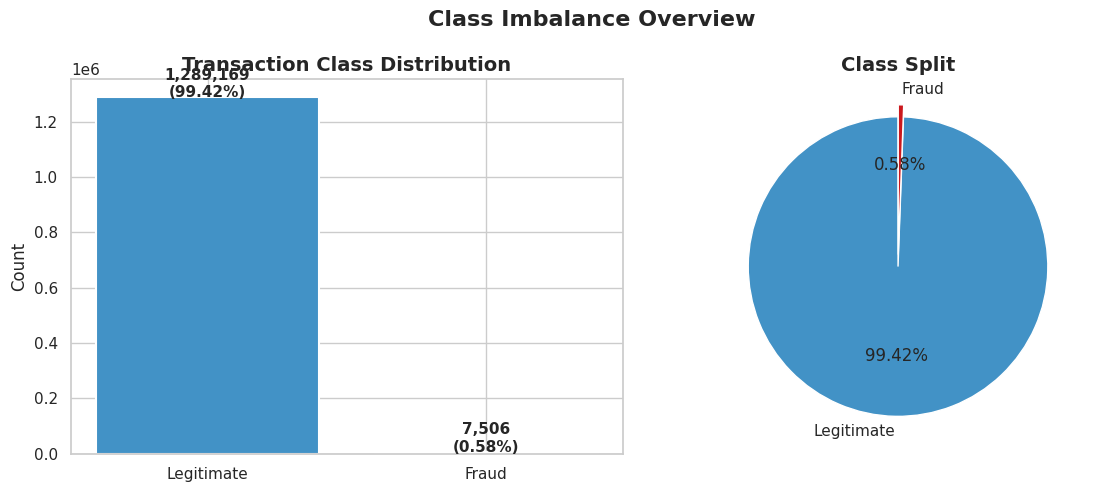

In [7]:
print("=" * 60)
print("STEP 3 — TARGET VARIABLE (CLASS IMBALANCE)")
print("=" * 60)

class_counts = df['is_fraud'].value_counts()
class_pct    = df['is_fraud'].value_counts(normalize=True) * 100

print(f"\nLegitimate transactions : {class_counts[0]:>8,}  ({class_pct[0]:.3f}%)")
print(f"Fraudulent transactions : {class_counts[1]:>8,}  ({class_pct[1]:.3f}%)")
print(f"Imbalance ratio         : {class_counts[0]/class_counts[1]:.1f} : 1")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].bar(['Legitimate', 'Fraud'], class_counts.values,
            color=['#4292c6', '#cb181d'], edgecolor='white', linewidth=1.5)
axes[0].set_title('Transaction Class Distribution', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate(class_counts.values):
    axes[0].text(i, v + 500, f'{v:,}\n({class_pct.values[i]:.2f}%)',
                 ha='center', fontsize=11, fontweight='bold')

axes[1].pie(class_counts.values,
            labels=['Legitimate', 'Fraud'],
            autopct='%1.2f%%',
            colors=['#4292c6', '#cb181d'],
            startangle=90, explode=(0, 0.08))
axes[1].set_title('Class Split', fontsize=14, fontweight='bold')

plt.suptitle('Class Imbalance Overview', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

STEP 4 — TRANSACTION AMOUNT ANALYSIS

Metric                    Legitimate           Fraud
----------------------------------------------------
Mean                           67.67          531.32
Median                         47.28          396.50
Std Dev                       154.01          390.53
Min                             1.00            1.06
Max                         28948.90         1376.04
25th pct                        9.61          245.66
75th pct                       82.54          900.88

Mann-Whitney U test  stat=1600757646  p-value=0.0000e+00
→ Fraud and legitimate amounts are statistically DIFFERENT (α=0.05)


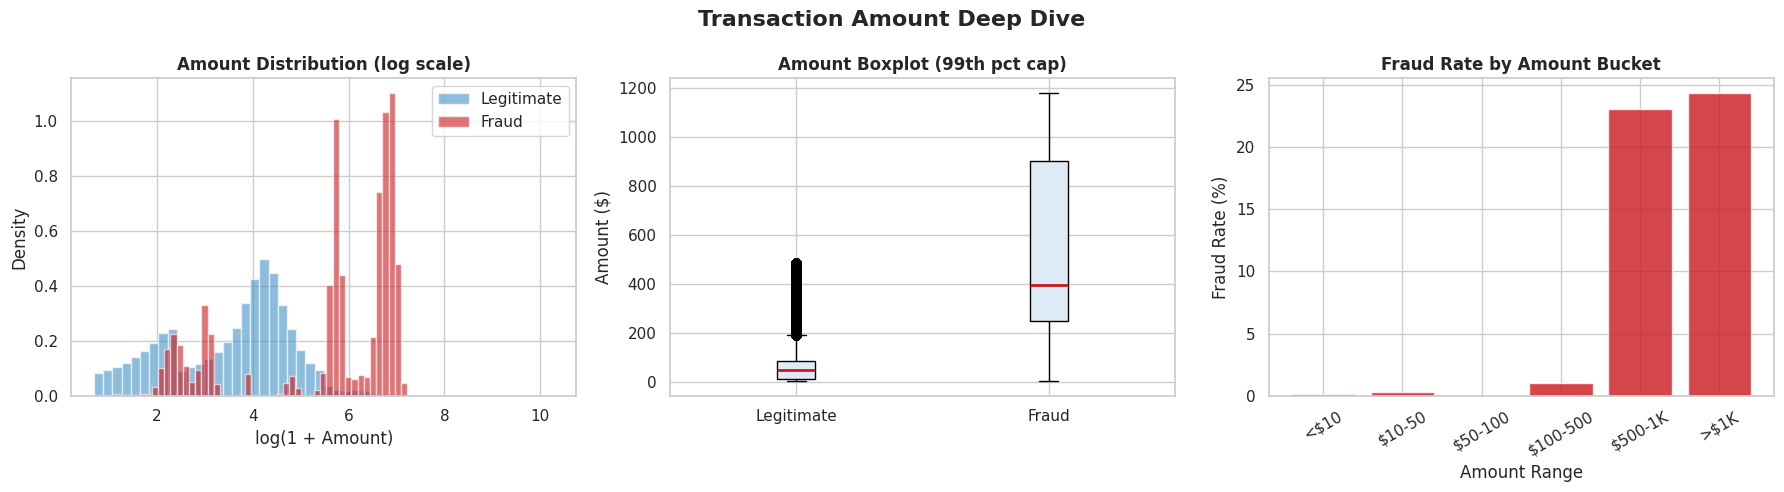

In [8]:
print("=" * 60)
print("STEP 4 — TRANSACTION AMOUNT ANALYSIS")
print("=" * 60)

legit_amt = df[df['is_fraud'] == 0]['amt']
fraud_amt = df[df['is_fraud'] == 1]['amt']

print(f"\n{'Metric':<20} {'Legitimate':>15} {'Fraud':>15}")
print("-" * 52)
for metric, fn in [('Mean', np.mean), ('Median', np.median),
                   ('Std Dev', np.std), ('Min', np.min), ('Max', np.max),
                   ('25th pct', lambda x: np.percentile(x, 25)),
                   ('75th pct', lambda x: np.percentile(x, 75))]:
    print(f"{metric:<20} {fn(legit_amt):>15.2f} {fn(fraud_amt):>15.2f}")

stat, pval = stats.mannwhitneyu(legit_amt, fraud_amt, alternative='two-sided')
print(f"\nMann-Whitney U test  stat={stat:.0f}  p-value={pval:.4e}")
print(f"→ Fraud and legitimate amounts are statistically "
      f"{'DIFFERENT' if pval < 0.05 else 'NOT DIFFERENT'} (α=0.05)")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].hist(np.log1p(legit_amt), bins=50, alpha=0.6,
             color='#4292c6', label='Legitimate', density=True)
axes[0].hist(np.log1p(fraud_amt), bins=50, alpha=0.6,
             color='#cb181d', label='Fraud', density=True)
axes[0].set_xlabel('log(1 + Amount)')
axes[0].set_ylabel('Density')
axes[0].set_title('Amount Distribution (log scale)', fontweight='bold')
axes[0].legend()

axes[1].boxplot([legit_amt.clip(upper=legit_amt.quantile(0.99)),
                 fraud_amt.clip(upper=fraud_amt.quantile(0.99))],
                labels=['Legitimate', 'Fraud'], patch_artist=True,
                boxprops=dict(facecolor='#deebf7'),
                medianprops=dict(color='#cb181d', linewidth=2))
axes[1].set_ylabel('Amount ($)')
axes[1].set_title('Amount Boxplot (99th pct cap)', fontweight='bold')

df['amt_bucket'] = pd.cut(df['amt'],
                           bins=[0, 10, 50, 100, 500, 1000, 10000],
                           labels=['<$10','$10-50','$50-100',
                                   '$100-500','$500-1K','>$1K'])
fraud_by_amt = df.groupby('amt_bucket')['is_fraud'].mean() * 100
axes[2].bar(fraud_by_amt.index.astype(str), fraud_by_amt.values,
            color='#cb181d', alpha=0.8)
axes[2].set_xlabel('Amount Range')
axes[2].set_ylabel('Fraud Rate (%)')
axes[2].set_title('Fraud Rate by Amount Bucket', fontweight='bold')
axes[2].tick_params(axis='x', rotation=30)

plt.suptitle('Transaction Amount Deep Dive', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

STEP 5 — TEMPORAL PATTERNS


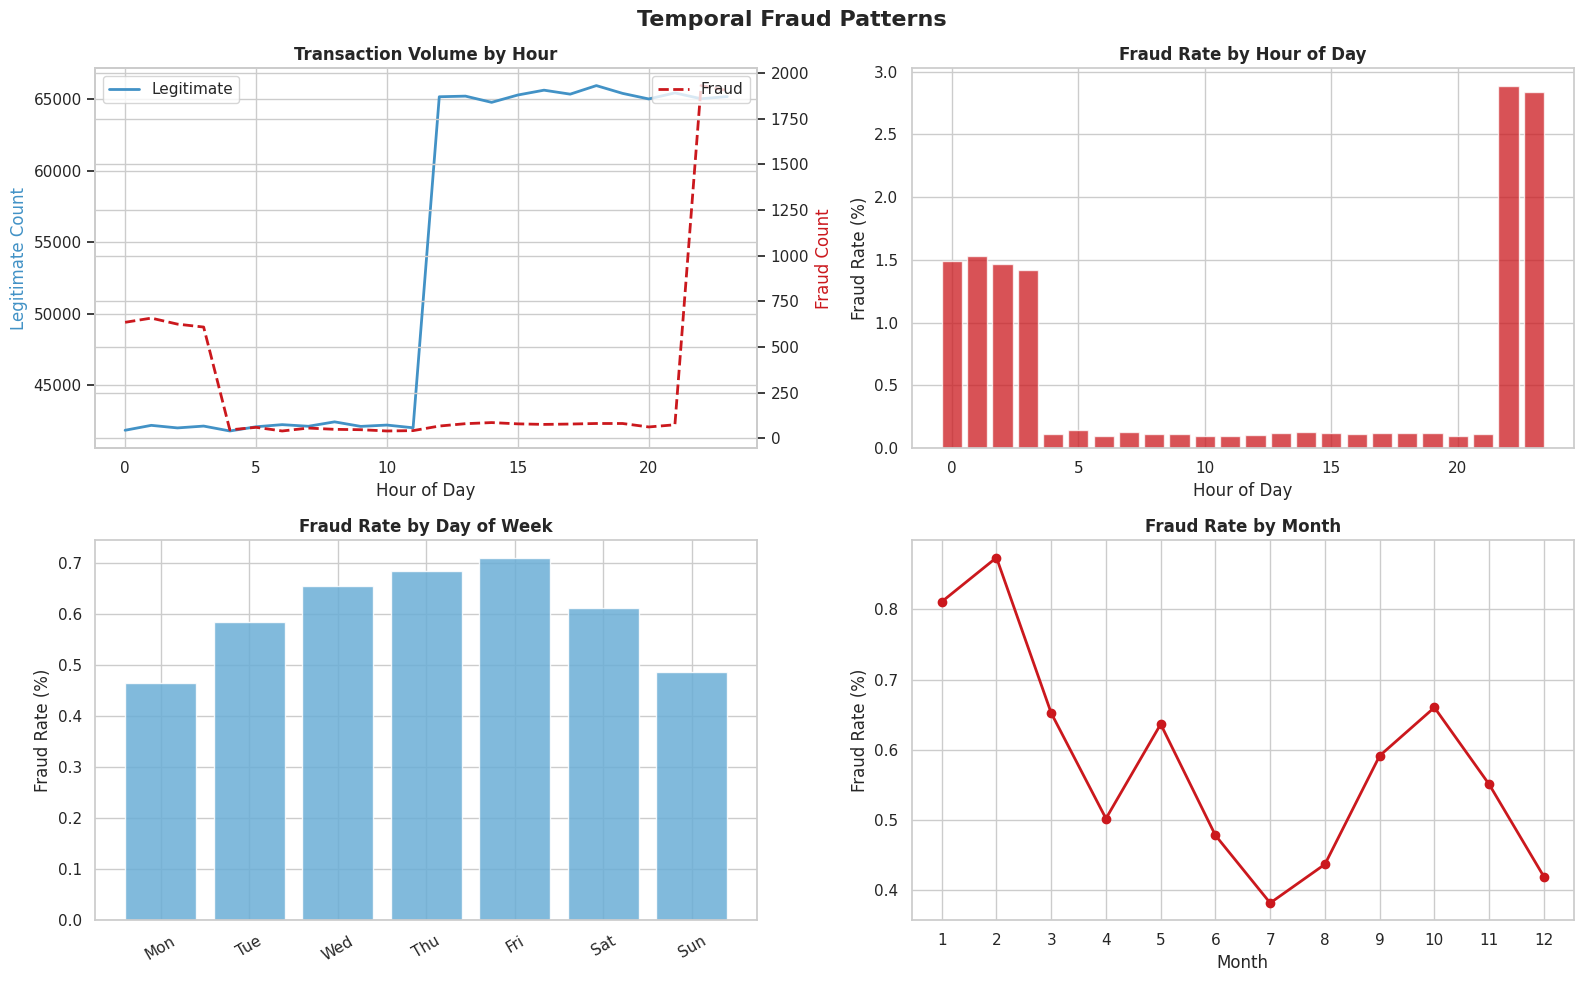

In [9]:
print("=" * 60)
print("STEP 5 — TEMPORAL PATTERNS")
print("=" * 60)

df['trans_dt']  = pd.to_datetime(df['trans_date_trans_time'])
df['Hour']      = df['trans_dt'].dt.hour
df['DayOfWeek'] = df['trans_dt'].dt.day_name()
df['Month']     = df['trans_dt'].dt.month

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Hourly volume dual axis
hourly = df.groupby(['Hour', 'is_fraud']).size().unstack(fill_value=0)
hourly.columns = ['Legitimate', 'Fraud']
axes[0,0].plot(hourly.index, hourly['Legitimate'],
               color='#4292c6', label='Legitimate', linewidth=2)
ax2 = axes[0,0].twinx()
ax2.plot(hourly.index, hourly['Fraud'],
         color='#cb181d', label='Fraud', linewidth=2, linestyle='--')
axes[0,0].set_xlabel('Hour of Day')
axes[0,0].set_ylabel('Legitimate Count', color='#4292c6')
ax2.set_ylabel('Fraud Count', color='#cb181d')
axes[0,0].set_title('Transaction Volume by Hour', fontweight='bold')
axes[0,0].legend(loc='upper left')
ax2.legend(loc='upper right')

# Fraud rate by hour
fraud_rate_hour = df.groupby('Hour')['is_fraud'].mean() * 100
axes[0,1].bar(fraud_rate_hour.index, fraud_rate_hour.values,
              color='#cb181d', alpha=0.75)
axes[0,1].set_xlabel('Hour of Day')
axes[0,1].set_ylabel('Fraud Rate (%)')
axes[0,1].set_title('Fraud Rate by Hour of Day', fontweight='bold')

# Fraud rate by day of week
day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
fraud_rate_day = df.groupby('DayOfWeek')['is_fraud'].mean() * 100
fraud_rate_day = fraud_rate_day.reindex(day_order)
axes[1,0].bar(range(7), fraud_rate_day.values, color='#6baed6', alpha=0.85)
axes[1,0].set_xticks(range(7))
axes[1,0].set_xticklabels([d[:3] for d in day_order], rotation=30)
axes[1,0].set_ylabel('Fraud Rate (%)')
axes[1,0].set_title('Fraud Rate by Day of Week', fontweight='bold')

# Monthly fraud rate
fraud_rate_month = df.groupby('Month')['is_fraud'].mean() * 100
axes[1,1].plot(fraud_rate_month.index, fraud_rate_month.values,
               marker='o', color='#cb181d', linewidth=2)
axes[1,1].set_xlabel('Month')
axes[1,1].set_ylabel('Fraud Rate (%)')
axes[1,1].set_title('Fraud Rate by Month', fontweight='bold')
axes[1,1].set_xticks(range(1, 13))

plt.suptitle('Temporal Fraud Patterns', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

STEP 6 — CATEGORICAL FEATURE ANALYSIS


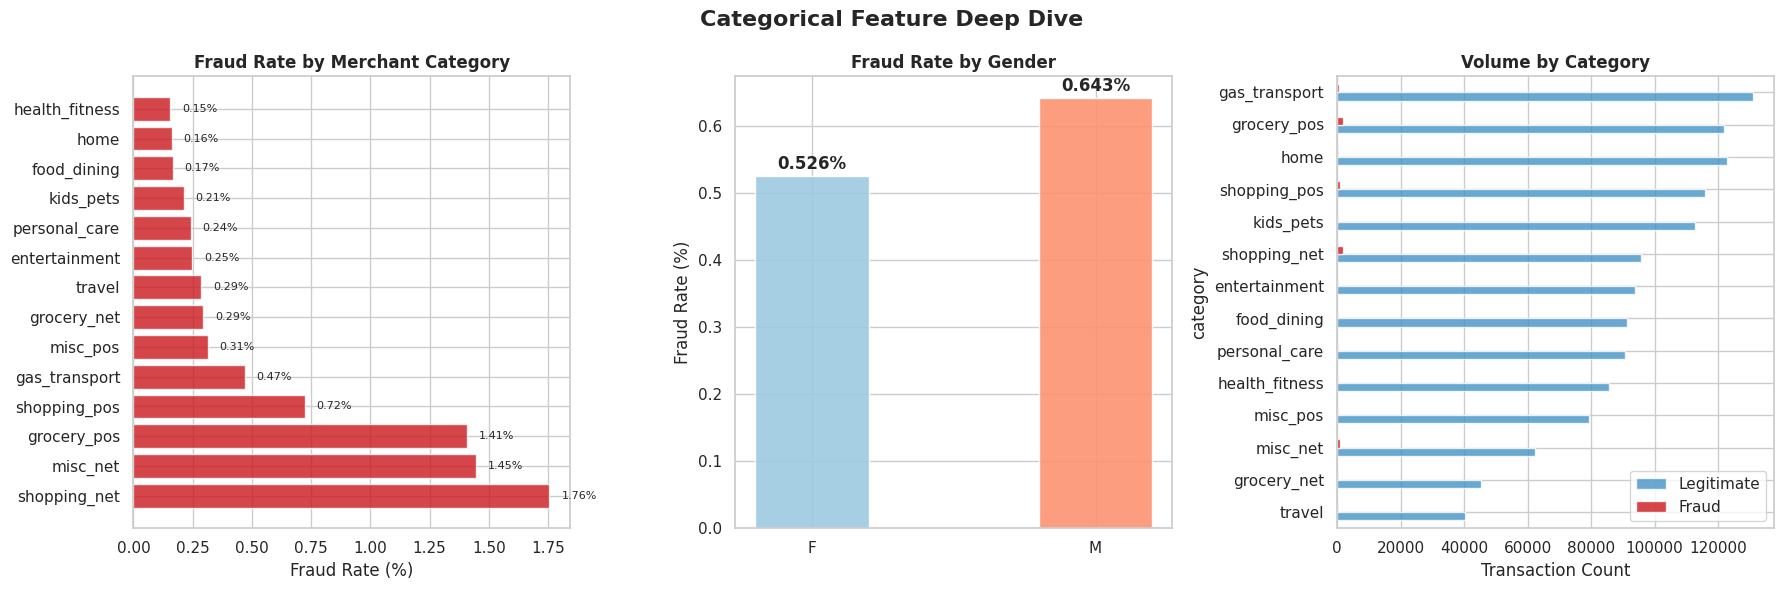


Top 5 highest fraud rate categories:
category
shopping_net     1.756149
misc_net         1.445795
grocery_pos      1.409761
shopping_pos     0.722538
gas_transport    0.469394


In [10]:
print("=" * 60)
print("STEP 6 — CATEGORICAL FEATURE ANALYSIS")
print("=" * 60)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

fraud_by_cat = (df.groupby('category')['is_fraud']
                  .mean().sort_values(ascending=False) * 100)
axes[0].barh(fraud_by_cat.index, fraud_by_cat.values,
             color='#cb181d', alpha=0.8)
axes[0].set_xlabel('Fraud Rate (%)')
axes[0].set_title('Fraud Rate by Merchant Category', fontweight='bold')
for i, v in enumerate(fraud_by_cat.values):
    axes[0].text(v + 0.05, i, f'{v:.2f}%', va='center', fontsize=8)

fraud_by_gender = df.groupby('gender')['is_fraud'].mean() * 100
axes[1].bar(fraud_by_gender.index, fraud_by_gender.values,
            color=['#9ecae1', '#fc9272'], alpha=0.9, width=0.4)
axes[1].set_ylabel('Fraud Rate (%)')
axes[1].set_title('Fraud Rate by Gender', fontweight='bold')
for i, (k, v) in enumerate(fraud_by_gender.items()):
    axes[1].text(i, v + 0.01, f'{v:.3f}%', ha='center', fontweight='bold')

cat_volume = df.groupby(['category', 'is_fraud']).size().unstack(fill_value=0)
cat_volume.columns = ['Legitimate', 'Fraud']
cat_volume['Total'] = cat_volume.sum(axis=1)
cat_volume = cat_volume.sort_values('Total', ascending=True)
cat_volume[['Legitimate', 'Fraud']].plot(
    kind='barh', ax=axes[2], color=['#4292c6', '#cb181d'], alpha=0.8)
axes[2].set_xlabel('Transaction Count')
axes[2].set_title('Volume by Category', fontweight='bold')

plt.suptitle('Categorical Feature Deep Dive', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nTop 5 highest fraud rate categories:")
print(fraud_by_cat.head().to_string())

STEP 7 — CARDHOLDER BEHAVIOUR ANALYSIS

Avg transactions per cardholder : 1319.1
Max transactions per cardholder : 3123
Cards with at least 1 fraud txn : 762
% of cards ever defrauded       : 77.5%


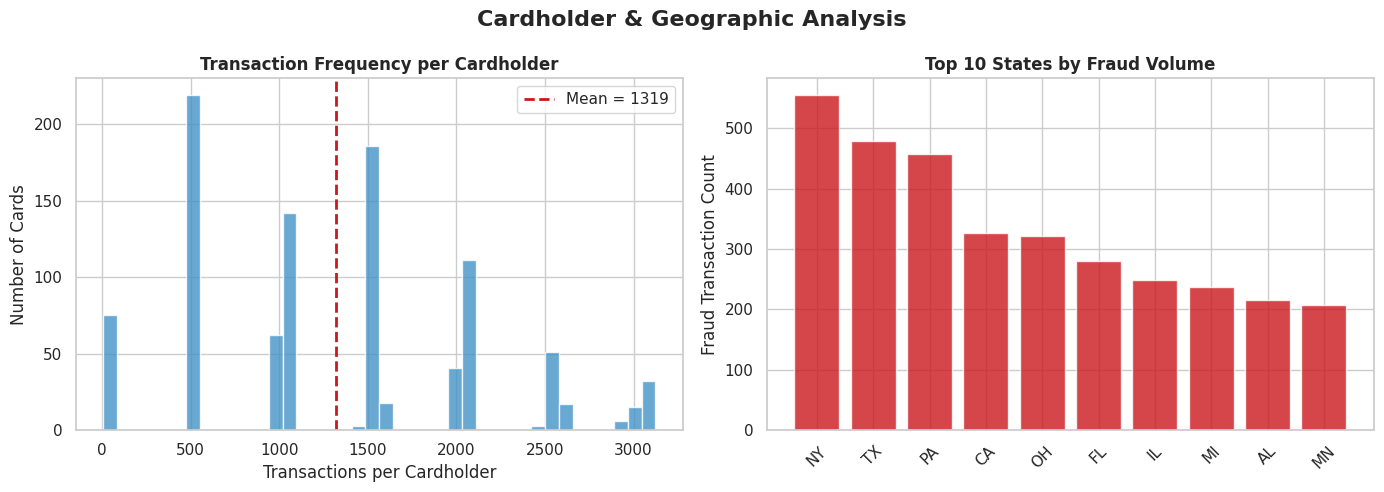

In [11]:
print("=" * 60)
print("STEP 7 — CARDHOLDER BEHAVIOUR ANALYSIS")
print("=" * 60)

txn_per_card   = df.groupby('cc_num').size()
fraud_per_card = df[df['is_fraud']==1].groupby('cc_num').size()

print(f"\nAvg transactions per cardholder : {txn_per_card.mean():.1f}")
print(f"Max transactions per cardholder : {txn_per_card.max()}")
print(f"Cards with at least 1 fraud txn : {len(fraud_per_card):,}")
print(f"% of cards ever defrauded       : {len(fraud_per_card)/len(txn_per_card)*100:.1f}%")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(txn_per_card.values, bins=40,
             color='#4292c6', alpha=0.8, edgecolor='white')
axes[0].axvline(txn_per_card.mean(), color='#cb181d', linestyle='--',
                linewidth=2, label=f'Mean = {txn_per_card.mean():.0f}')
axes[0].set_xlabel('Transactions per Cardholder')
axes[0].set_ylabel('Number of Cards')
axes[0].set_title('Transaction Frequency per Cardholder', fontweight='bold')
axes[0].legend()

fraud_by_state = (df[df['is_fraud']==1]
                  .groupby('state').size()
                  .sort_values(ascending=False).head(10))
axes[1].bar(fraud_by_state.index, fraud_by_state.values,
            color='#cb181d', alpha=0.8)
axes[1].set_ylabel('Fraud Transaction Count')
axes[1].set_title('Top 10 States by Fraud Volume', fontweight='bold')
axes[1].tick_params(axis='x', rotation=45)

plt.suptitle('Cardholder & Geographic Analysis', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

STEP 8 — CORRELATION ANALYSIS


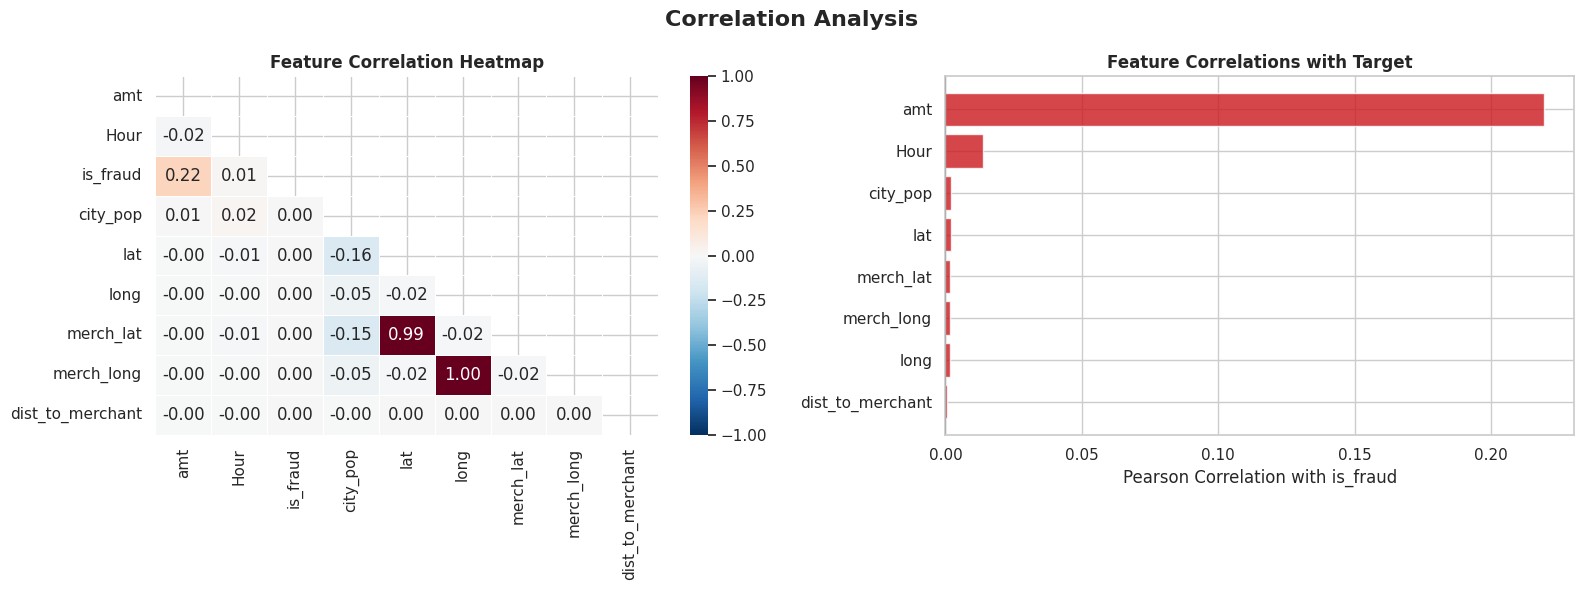


Correlations with is_fraud (sorted):
dist_to_merchant    0.000434
long                0.001721
merch_long          0.001721
merch_lat           0.001741
lat                 0.001894
city_pop            0.002136
Hour                0.013799
amt                 0.219404

Avg cardholder-merchant distance:
  Legitimate : 0.7657
  Fraud      : 0.7673


In [12]:
print("=" * 60)
print("STEP 8 — CORRELATION ANALYSIS")
print("=" * 60)

df_num = df[['amt', 'Hour', 'is_fraud', 'city_pop',
             'lat', 'long', 'merch_lat', 'merch_long']].copy()
df_num['dist_to_merchant'] = np.sqrt(
    (df['lat'] - df['merch_lat'])**2 +
    (df['long'] - df['merch_long'])**2
)

corr = df_num.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(corr, mask=mask, ax=axes[0], annot=True, fmt='.2f',
            cmap='RdBu_r', vmin=-1, vmax=1, linewidths=0.5)
axes[0].set_title('Feature Correlation Heatmap', fontweight='bold')

corr_target  = corr['is_fraud'].drop('is_fraud').sort_values()
colors_bar   = ['#cb181d' if v > 0 else '#4292c6' for v in corr_target.values]
axes[1].barh(corr_target.index, corr_target.values, color=colors_bar, alpha=0.8)
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_xlabel('Pearson Correlation with is_fraud')
axes[1].set_title('Feature Correlations with Target', fontweight='bold')

plt.suptitle('Correlation Analysis', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nCorrelations with is_fraud (sorted):")
print(corr_target.to_string())

print(f"\nAvg cardholder-merchant distance:")
print(f"  Legitimate : {df_num[df['is_fraud']==0]['dist_to_merchant'].mean():.4f}")
print(f"  Fraud      : {df_num[df['is_fraud']==1]['dist_to_merchant'].mean():.4f}")

STEP 9 — OUTLIER ANALYSIS

amt:
  Z-score outliers (|z|>3) : 12,738 (0.98%)
  IQR outliers             : 67,290 (5.19%)

city_pop:
  Z-score outliers (|z|>3) : 32,814 (2.53%)
  IQR outliers             : 242,674 (18.72%)


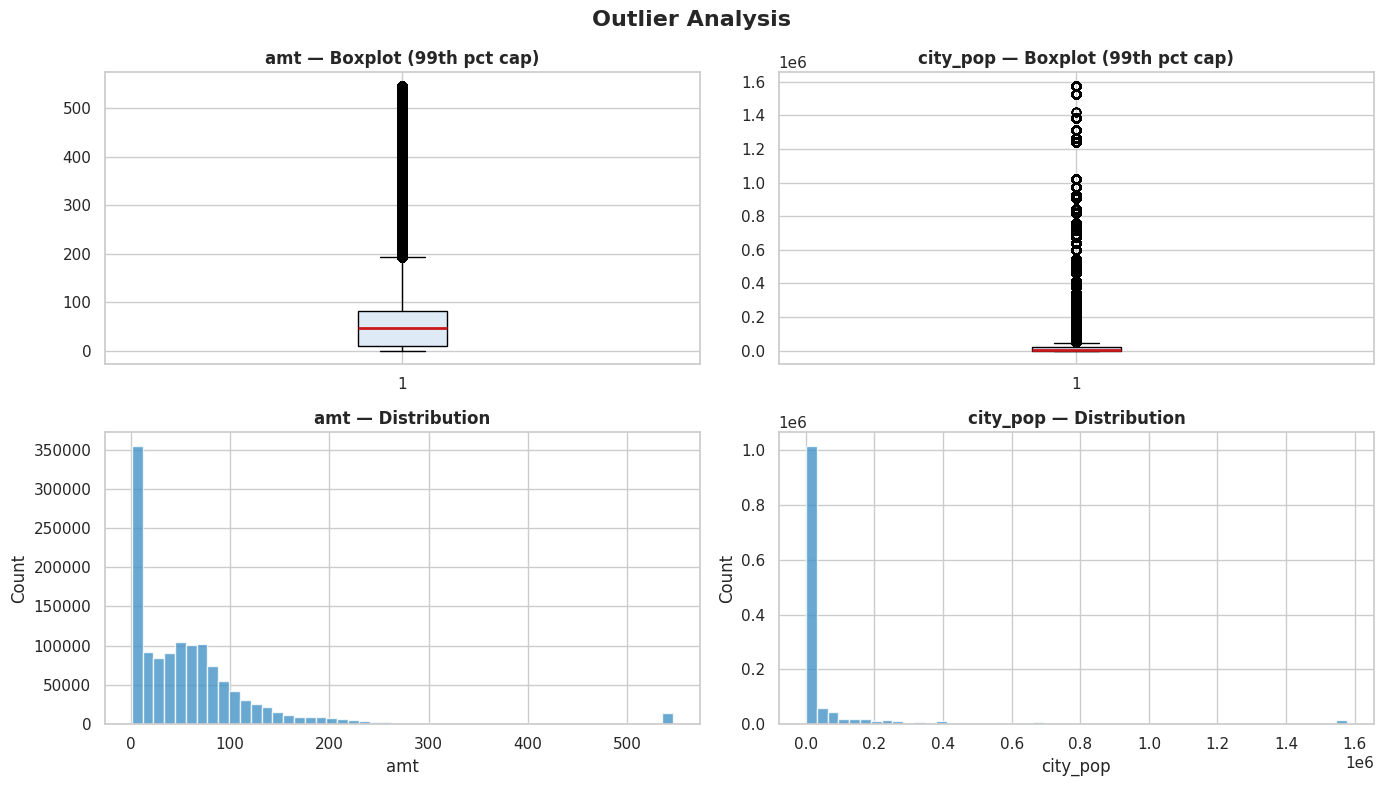

In [13]:
print("=" * 60)
print("STEP 9 — OUTLIER ANALYSIS")
print("=" * 60)

numeric_cols = ['amt', 'city_pop']
fig, axes = plt.subplots(2, len(numeric_cols), figsize=(14, 8))

for i, col in enumerate(numeric_cols):
    data = df[col]

    z_scores   = np.abs(stats.zscore(data))
    n_outliers = (z_scores > 3).sum()
    Q1, Q3     = data.quantile(0.25), data.quantile(0.75)
    IQR        = Q3 - Q1
    iqr_out    = ((data < Q1 - 1.5*IQR) | (data > Q3 + 1.5*IQR)).sum()

    print(f"\n{col}:")
    print(f"  Z-score outliers (|z|>3) : {n_outliers:,} ({n_outliers/len(data)*100:.2f}%)")
    print(f"  IQR outliers             : {iqr_out:,} ({iqr_out/len(data)*100:.2f}%)")

    axes[0, i].boxplot(data.clip(upper=data.quantile(0.99)),
                       patch_artist=True,
                       boxprops=dict(facecolor='#deebf7'),
                       medianprops=dict(color='#cb181d', linewidth=2))
    axes[0, i].set_title(f'{col} — Boxplot (99th pct cap)', fontweight='bold')

    axes[1, i].hist(data.clip(upper=data.quantile(0.99)), bins=50,
                    color='#4292c6', alpha=0.8, edgecolor='white')
    axes[1, i].set_xlabel(col)
    axes[1, i].set_ylabel('Count')
    axes[1, i].set_title(f'{col} — Distribution', fontweight='bold')

plt.suptitle('Outlier Analysis', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

In [14]:
print("=" * 60)
print("STEP 10 — DATA CLEANING & FEATURE ENGINEERING")
print("=" * 60)

df_clean = df_raw.copy()

# 1. Parse datetime
df_clean['trans_dt']  = pd.to_datetime(df_clean['trans_date_trans_time'])
df_clean['Hour']      = df_clean['trans_dt'].dt.hour
df_clean['DayOfWeek'] = df_clean['trans_dt'].dt.dayofweek
df_clean['Month']     = df_clean['trans_dt'].dt.month

# 2. Cyclical time encoding
df_clean['Hour_Sin']  = np.sin(2 * np.pi * df_clean['Hour']      / 24)
df_clean['Hour_Cos']  = np.cos(2 * np.pi * df_clean['Hour']      / 24)
df_clean['Day_Sin']   = np.sin(2 * np.pi * df_clean['DayOfWeek'] / 7)
df_clean['Day_Cos']   = np.cos(2 * np.pi * df_clean['DayOfWeek'] / 7)
df_clean['Month_Sin'] = np.sin(2 * np.pi * df_clean['Month']     / 12)
df_clean['Month_Cos'] = np.cos(2 * np.pi * df_clean['Month']     / 12)

# 3. Cardholder-to-merchant distance
df_clean['dist_to_merchant'] = np.sqrt(
    (df_clean['lat'] - df_clean['merch_lat'])**2 +
    (df_clean['long'] - df_clean['merch_long'])**2
)

# 4. Age from date of birth
df_clean['dob_dt'] = pd.to_datetime(df_clean['dob'])
df_clean['age']    = (df_clean['trans_dt'] - df_clean['dob_dt']).dt.days // 365

# 5. Encode cc_num as integer ID (kept for HMM grouping)
df_clean['cc_num'] = df_clean['cc_num'].astype('category').cat.codes

# 6. Encode remaining categoricals
df_clean['gender']   = (df_clean['gender'] == 'M').astype(int)
df_clean['category'] = df_clean['category'].astype('category').cat.codes

# 7. Drop raw / string columns
df_clean.drop(['trans_date_trans_time', 'trans_dt', 'dob_dt',
               'Hour', 'DayOfWeek', 'Month',
               'merchant', 'first', 'last', 'street',
               'city', 'state', 'job', 'dob', 'trans_num', 'zip'],
              axis=1, inplace=True)

X = df_clean.drop('is_fraud', axis=1)
y = df_clean['is_fraud']

print(f"Remaining string cols : {list(X.dtypes[X.dtypes == 'object'].index) or 'None ✓'}")
print(f"Missing values        : {X.isnull().sum().sum()} ✓")
print(f"\nFinal feature set ({X.shape[1]} features):")
for col in X.columns:
    print(f"  {col}")

STEP 10 — DATA CLEANING & FEATURE ENGINEERING
Remaining string cols : None ✓
Missing values        : 0 ✓

Final feature set (19 features):
  Unnamed: 0
  cc_num
  category
  amt
  gender
  lat
  long
  city_pop
  unix_time
  merch_lat
  merch_long
  Hour_Sin
  Hour_Cos
  Day_Sin
  Day_Cos
  Month_Sin
  Month_Cos
  dist_to_merchant
  age


In [15]:
print("=" * 60)
print("STEP 11 — STRATIFIED TRAIN-TEST SPLIT")
print("=" * 60)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train shape   : {X_train.shape}")
print(f"Test shape    : {X_test.shape}")
print(f"Train fraud % : {y_train.mean()*100:.3f}%")
print(f"Test  fraud % : {y_test.mean()*100:.3f}%")
print(f"Fraud in train: {y_train.sum():,}")
print(f"Fraud in test : {y_test.sum():,}")

STEP 11 — STRATIFIED TRAIN-TEST SPLIT
Train shape   : (1037340, 19)
Test shape    : (259335, 19)
Train fraud % : 0.579%
Test  fraud % : 0.579%
Fraud in train: 6,005
Fraud in test : 1,501


In [16]:
print("=" * 60)
print("STEP 12 — FEATURE SCALING")
print("=" * 60)

scaler = StandardScaler()

# Pull cc_num out — it's an ID for HMM grouping, not a model feature
X_train_ids  = X_train['cc_num'].values
X_test_ids   = X_test['cc_num'].values

X_train_noid = X_train.drop('cc_num', axis=1)
X_test_noid  = X_test.drop('cc_num', axis=1)

# Fit ONLY on training data — no leakage into test
X_train_scaled = scaler.fit_transform(X_train_noid)
X_test_scaled  = scaler.transform(X_test_noid)

print(f"Scaler fitted on train only — no leakage ✓")
print(f"Train scaled shape : {X_train_scaled.shape}")
print(f"Test  scaled shape : {X_test_scaled.shape}")
print(f"Post-scaling mean  : {X_train_scaled.mean():.6f}  (expected ~0)")
print(f"Post-scaling std   : {X_train_scaled.std():.6f}   (expected ~1)")

STEP 12 — FEATURE SCALING
Scaler fitted on train only — no leakage ✓
Train scaled shape : (1037340, 18)
Test  scaled shape : (259335, 18)
Post-scaling mean  : 0.000000  (expected ~0)
Post-scaling std   : 1.000000   (expected ~1)


In [17]:
print("=" * 60)
print("STEP 13 — GAUSSIAN HMM TRAINING")
print("=" * 60)

# Build working df: scaled features + cardholder ID + label
train_df = pd.DataFrame(X_train_scaled, index=X_train.index)
train_df['cc_num']   = X_train_ids
train_df['is_fraud'] = y_train.values

sequences, lengths = [], []

# Group by real cardholder — genuine per-card sequences
for card_id, group in train_df[train_df['is_fraud'] == 0].groupby('cc_num'):
    seq = group.drop(['cc_num', 'is_fraud'], axis=1).values
    if len(seq) >= 2:          # minimum 2 steps needed for transitions
        sequences.append(seq)
        lengths.append(len(seq))

X_seq_concat = np.vstack(sequences)

hmm_model = hmm.GaussianHMM(
    n_components=4,
    covariance_type="diag",
    n_iter=100,
    random_state=42
)
hmm_model.fit(X_seq_concat, lengths)

print(f"HMM trained on {len(sequences):,} real cardholder sequences")
print(f"Total observations              : {X_seq_concat.shape[0]:,}")
print(f"Genuine transition steps learned: {sum(lengths) - len(lengths):,}")
print(f"\nLearned initial state distribution (π):")
print(np.round(hmm_model.startprob_, 4))
print(f"\nLearned transition matrix (A):")
print(np.round(hmm_model.transmat_, 4))

STEP 13 — GAUSSIAN HMM TRAINING
HMM trained on 908 real cardholder sequences
Total observations              : 1,031,335
Genuine transition steps learned: 1,030,427

Learned initial state distribution (π):
[0.1397 0.1205 0.2473 0.4925]

Learned transition matrix (A):
[[2.361e-01 3.000e-04 1.770e-02 7.459e-01]
 [4.000e-04 9.932e-01 6.400e-03 0.000e+00]
 [1.060e-02 3.100e-03 9.539e-01 3.250e-02]
 [2.346e-01 0.000e+00 1.630e-02 7.491e-01]]


STEP 14 — HMM SEQUENTIAL SCORING
Scoring training samples (may take a few minutes)...
Scoring test samples...

Hybrid train shape : (1037340, 19)
Hybrid test shape  : (259335, 19)
HMM score range (train): [-786.85, -12.10]
HMM score range (test) : [-877.37, -11.60]


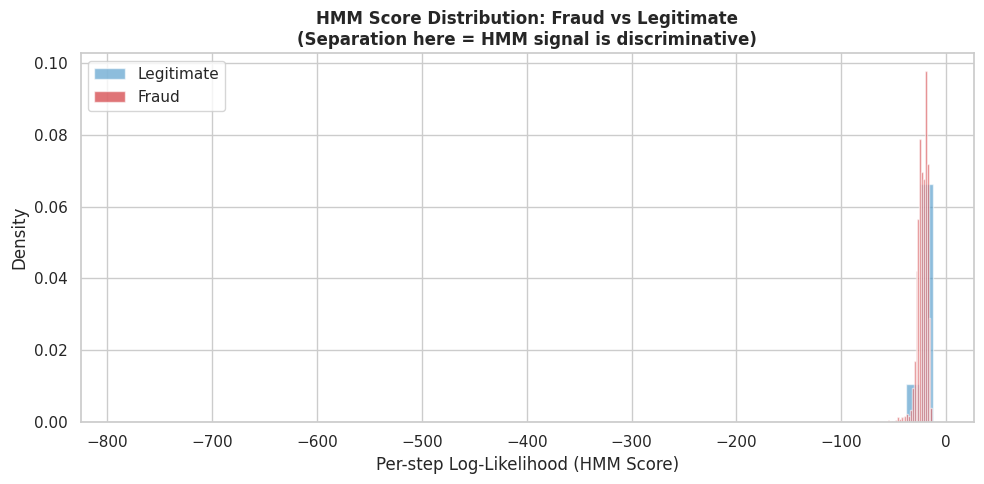

In [18]:
print("=" * 60)
print("STEP 14 — HMM SEQUENTIAL SCORING")
print("=" * 60)

def score_by_cardholder(scaled_array, card_ids, hmm_model, window_size=6):
    """
    Score each transaction using a window of up to window_size
    consecutive transactions from the same cardholder.
    Per-step normalisation ensures scores are comparable across positions.
    """
    scores  = np.zeros(len(scaled_array))
    df_temp = pd.DataFrame(scaled_array)
    df_temp['cc_num'] = card_ids

    for card_id, group in df_temp.groupby('cc_num'):
        seq = group.drop('cc_num', axis=1).values
        for i in range(len(seq)):
            window = seq[max(0, i - window_size + 1):i + 1]
            scores[group.index[i]] = hmm_model.score(window) / len(window)

    return scores

print("Scoring training samples (may take a few minutes)...")
train_hmm_scores = score_by_cardholder(X_train_scaled, X_train_ids, hmm_model)

print("Scoring test samples...")
test_hmm_scores = score_by_cardholder(X_test_scaled, X_test_ids, hmm_model)

# Append HMM score as final feature
X_train_hybrid = np.column_stack((X_train_scaled, train_hmm_scores))
X_test_hybrid  = np.column_stack((X_test_scaled,  test_hmm_scores))

print(f"\nHybrid train shape : {X_train_hybrid.shape}")
print(f"Hybrid test shape  : {X_test_hybrid.shape}")
print(f"HMM score range (train): [{train_hmm_scores.min():.2f}, {train_hmm_scores.max():.2f}]")
print(f"HMM score range (test) : [{test_hmm_scores.min():.2f}, {test_hmm_scores.max():.2f}]")

# Visualise: does HMM score separate fraud from legit?
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(train_hmm_scores[y_train.values == 0], bins=60,
        alpha=0.6, color='#4292c6', label='Legitimate', density=True)
ax.hist(train_hmm_scores[y_train.values == 1], bins=60,
        alpha=0.6, color='#cb181d', label='Fraud', density=True)
ax.set_xlabel('Per-step Log-Likelihood (HMM Score)')
ax.set_ylabel('Density')
ax.set_title('HMM Score Distribution: Fraud vs Legitimate\n'
             '(Separation here = HMM signal is discriminative)',
             fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

In [19]:
print("=" * 60)
print("STEP 15 — ABLATION STUDY CONFIGURATION")
print("=" * 60)

ratio = float(y_train.value_counts()[0] / y_train.value_counts()[1])
print(f"Class imbalance ratio (scale_pos_weight): {ratio:.1f}")

experiments = {
    "RF Baseline": {
        "X_train": X_train_scaled,
        "X_test" : X_test_scaled,
        "model"  : RandomForestClassifier(
            n_estimators=100, max_depth=12, min_samples_split=5,
            class_weight='balanced', random_state=42, n_jobs=-1)
    },
    "RF Hybrid (With HMM)": {
        "X_train": X_train_hybrid,
        "X_test" : X_test_hybrid,
        "model"  : RandomForestClassifier(
            n_estimators=100, max_depth=12, min_samples_split=5,
            class_weight='balanced', random_state=42, n_jobs=-1)
    },
    "XGB Baseline": {
        "X_train": X_train_scaled,
        "X_test" : X_test_scaled,
        "model"  : xgb.XGBClassifier(
            n_estimators=150, max_depth=6, learning_rate=0.1,
            scale_pos_weight=ratio, random_state=42,
            eval_metric='aucpr', n_jobs=-1)
    },
    "XGB Hybrid (With HMM)": {
        "X_train": X_train_hybrid,
        "X_test" : X_test_hybrid,
        "model"  : xgb.XGBClassifier(
            n_estimators=150, max_depth=6, learning_rate=0.1,
            scale_pos_weight=ratio, random_state=42,
            eval_metric='aucpr', n_jobs=-1)
    }
}

print(f"\nBaseline feature dims : {X_train_scaled.shape[1]}")
print(f"Hybrid feature dims   : {X_train_hybrid.shape[1]} (includes HMM score)")

STEP 15 — ABLATION STUDY CONFIGURATION
Class imbalance ratio (scale_pos_weight): 171.7

Baseline feature dims : 18
Hybrid feature dims   : 19 (includes HMM score)


In [20]:
print("=" * 60)
print("STEP 16 — MODEL TRAINING")
print("=" * 60)

results_proba = {}
results_pred  = {}

for name, config in experiments.items():
    print(f"  Training [{name}]... ", end="", flush=True)
    config["model"].fit(config["X_train"], y_train)
    results_proba[name] = config["model"].predict_proba(config["X_test"])[:, 1]
    results_pred[name]  = config["model"].predict(config["X_test"])
    print("Done.")

print("\nAll 4 models trained successfully.")

STEP 16 — MODEL TRAINING
  Training [RF Baseline]... Done.
  Training [RF Hybrid (With HMM)]... Done.
  Training [XGB Baseline]... Done.
  Training [XGB Hybrid (With HMM)]... Done.

All 4 models trained successfully.


In [21]:
print("=" * 60)
print("STEP 17 — PERFORMANCE EVALUATION")
print("=" * 60)

print("\n" + "=" * 90)
print(f"{'Model':<28} | {'Precision':>10} | {'Recall':>10} | "
      f"{'F1':>10} | {'PR-AUC':>10} | {'ROC-AUC':>10}")
print("=" * 90)

metrics_dict = {}
for name in experiments.keys():
    prec  = precision_score(y_test, results_pred[name])
    rec   = recall_score(y_test, results_pred[name])
    f1    = f1_score(y_test, results_pred[name])
    p_, r_, _ = precision_recall_curve(y_test, results_proba[name])
    pr_auc    = auc(r_, p_)
    fpr, tpr, _ = roc_curve(y_test, results_proba[name])
    roc_auc   = auc(fpr, tpr)
    metrics_dict[name] = dict(precision=prec, recall=rec, f1=f1,
                               pr_auc=pr_auc, roc_auc=roc_auc)
    print(f"{name:<28} | {prec:>10.4f} | {rec:>10.4f} | "
          f"{f1:>10.4f} | {pr_auc:>10.4f} | {roc_auc:>10.4f}")
print("=" * 90)

print("\nAblation delta (Hybrid − Baseline):")
for base, hybrid in [("RF Baseline", "RF Hybrid (With HMM)"),
                      ("XGB Baseline", "XGB Hybrid (With HMM)")]:
    d_pr = metrics_dict[hybrid]['pr_auc'] - metrics_dict[base]['pr_auc']
    d_f1 = metrics_dict[hybrid]['f1']     - metrics_dict[base]['f1']
    sym  = "↑" if d_pr > 0 else "↓"
    print(f"  {hybrid:<30} PR-AUC {sym}{abs(d_pr):.4f}  |  F1 {sym}{abs(d_f1):.4f}")

STEP 17 — PERFORMANCE EVALUATION

Model                        |  Precision |     Recall |         F1 |     PR-AUC |    ROC-AUC
RF Baseline                  |     0.2540 |     0.9087 |     0.3970 |     0.8140 |     0.9921
RF Hybrid (With HMM)         |     0.2560 |     0.9061 |     0.3992 |     0.7945 |     0.9912
XGB Baseline                 |     0.3336 |     0.9714 |     0.4967 |     0.9289 |     0.9986
XGB Hybrid (With HMM)        |     0.3538 |     0.9734 |     0.5190 |     0.9275 |     0.9986

Ablation delta (Hybrid − Baseline):
  RF Hybrid (With HMM)           PR-AUC ↓0.0194  |  F1 ↓0.0023
  XGB Hybrid (With HMM)          PR-AUC ↓0.0014  |  F1 ↓0.0223


STEP 18 — CONFUSION MATRICES


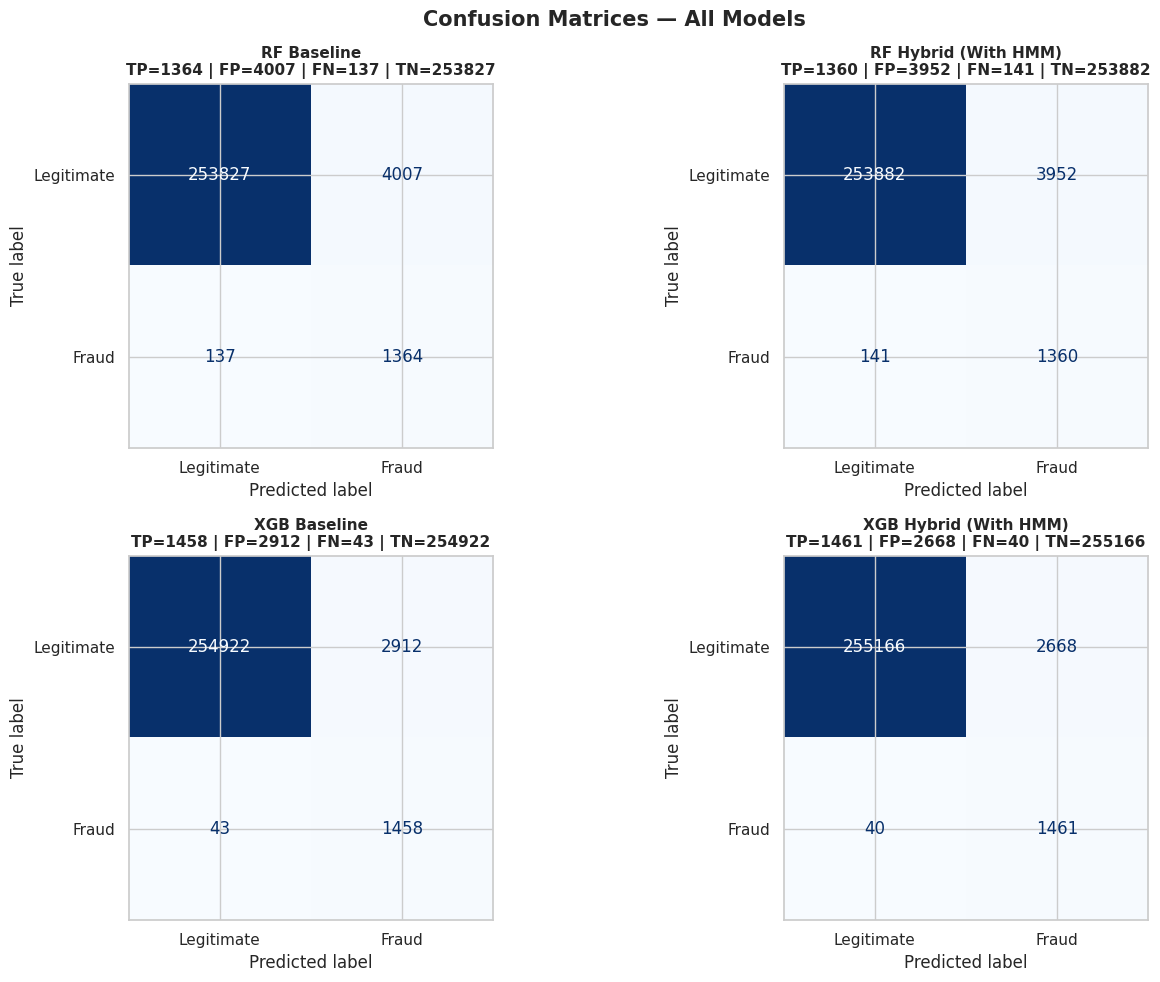

In [22]:
print("=" * 60)
print("STEP 18 — CONFUSION MATRICES")
print("=" * 60)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, name in enumerate(experiments.keys()):
    cm   = confusion_matrix(y_test, results_pred[name])
    disp = ConfusionMatrixDisplay(cm, display_labels=['Legitimate', 'Fraud'])
    disp.plot(ax=axes[i], colorbar=False, cmap='Blues')
    tn, fp, fn, tp = cm.ravel()
    axes[i].set_title(
        f'{name}\nTP={tp} | FP={fp} | FN={fn} | TN={tn}',
        fontsize=11, fontweight='bold')

plt.suptitle('Confusion Matrices — All Models', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

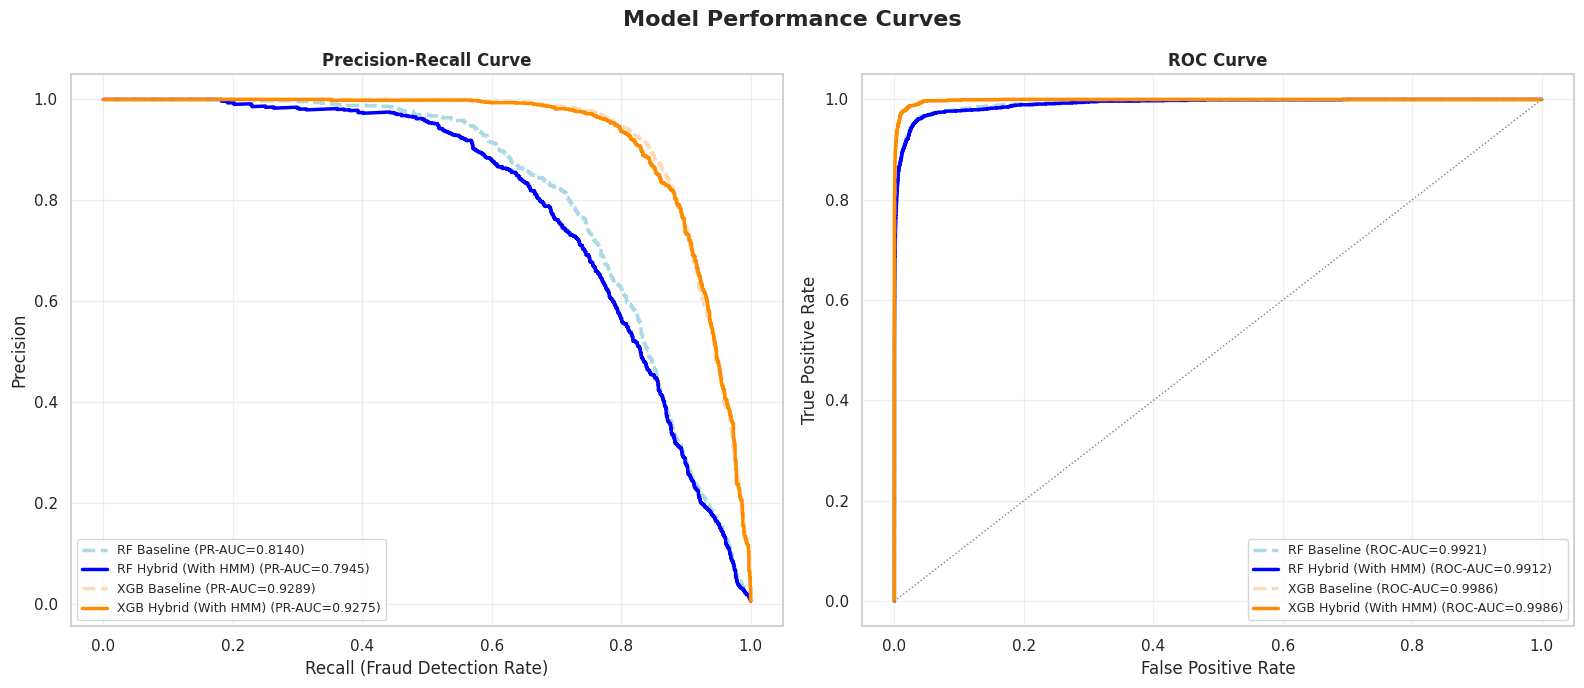

In [23]:
colors = {
    'RF Baseline'          : 'lightblue',
    'RF Hybrid (With HMM)' : 'blue',
    'XGB Baseline'         : 'peachpuff',
    'XGB Hybrid (With HMM)': 'darkorange'
}
styles = {
    'RF Baseline'          : '--',
    'RF Hybrid (With HMM)' : '-',
    'XGB Baseline'         : '--',
    'XGB Hybrid (With HMM)': '-'
}

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for name in experiments.keys():
    prec, rec, _ = precision_recall_curve(y_test, results_proba[name])
    pr_auc = auc(rec, prec)
    axes[0].plot(rec, prec, color=colors[name], linestyle=styles[name],
                 lw=2.5, label=f'{name} (PR-AUC={pr_auc:.4f})')
axes[0].set_xlabel('Recall (Fraud Detection Rate)')
axes[0].set_ylabel('Precision')
axes[0].set_title('Precision-Recall Curve', fontweight='bold')
axes[0].legend(loc='lower left', fontsize=9)
axes[0].grid(True, alpha=0.3)

for name in experiments.keys():
    fpr, tpr, _ = roc_curve(y_test, results_proba[name])
    roc_auc = auc(fpr, tpr)
    axes[1].plot(fpr, tpr, color=colors[name], linestyle=styles[name],
                 lw=2.5, label=f'{name} (ROC-AUC={roc_auc:.4f})')
axes[1].plot([0,1],[0,1], color='grey', lw=1, linestyle=':')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve', fontweight='bold')
axes[1].legend(loc='lower right', fontsize=9)
axes[1].grid(True, alpha=0.3)

plt.suptitle('Model Performance Curves', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

In [24]:
print("=" * 60)
print("STEP 19 — OPTIMAL THRESHOLD SELECTION")
print("=" * 60)

def find_best_threshold(y_true, y_proba):
    precs, recs, thresholds = precision_recall_curve(y_true, y_proba)
    f1s      = 2 * precs[:-1] * recs[:-1] / (precs[:-1] + recs[:-1] + 1e-9)
    best_idx = np.argmax(f1s)
    return thresholds[best_idx], f1s[best_idx], precs[best_idx], recs[best_idx]

print("\n" + "=" * 90)
print(f"{'Model':<28} | {'Opt Threshold':>14} | {'Precision':>10} | "
      f"{'Recall':>10} | {'F1 (opt)':>10}")
print("=" * 90)

for name in experiments.keys():
    thresh, best_f1, best_prec, best_rec = find_best_threshold(
        y_test, results_proba[name])
    print(f"{name:<28} | {thresh:>14.4f} | {best_prec:>10.4f} | "
          f"{best_rec:>10.4f} | {best_f1:>10.4f}")
print("=" * 90)
print("\nNote: Default threshold=0.5 is almost never optimal for imbalanced data.")

STEP 19 — OPTIMAL THRESHOLD SELECTION

Model                        |  Opt Threshold |  Precision |     Recall |   F1 (opt)
RF Baseline                  |         0.8134 |     0.8158 |     0.7142 |     0.7616
RF Hybrid (With HMM)         |         0.8068 |     0.7881 |     0.6889 |     0.7352
XGB Baseline                 |         0.9710 |     0.9207 |     0.8354 |     0.8760
XGB Hybrid (With HMM)        |         0.9775 |     0.9292 |     0.8128 |     0.8671

Note: Default threshold=0.5 is almost never optimal for imbalanced data.


STEP 20 — FEATURE IMPORTANCE


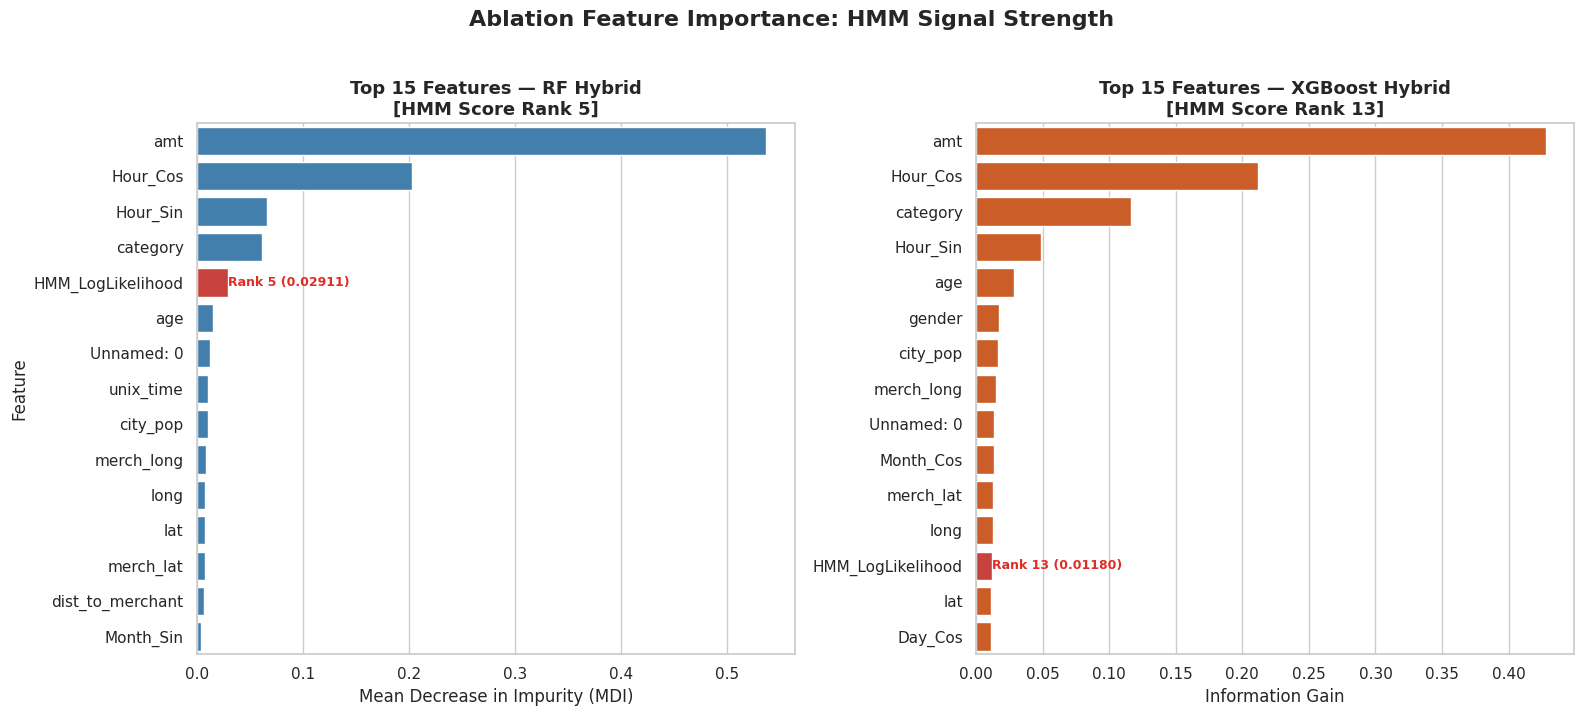

In [25]:
print("=" * 60)
print("STEP 20 — FEATURE IMPORTANCE")
print("=" * 60)

sns.set_theme(style="whitegrid")

feature_names    = list(X.drop('cc_num', axis=1).columns) + ['HMM_LogLikelihood']
rf_hybrid_model  = experiments["RF Hybrid (With HMM)"]["model"]
xgb_hybrid_model = experiments["XGB Hybrid (With HMM)"]["model"]

df_rf_all = pd.DataFrame({'Feature'   : feature_names,
                           'Importance': rf_hybrid_model.feature_importances_})
df_rf_all['Rank'] = df_rf_all['Importance'].rank(ascending=False).astype(int)
df_rf = df_rf_all.sort_values('Importance', ascending=False).head(15)

df_xgb_all = pd.DataFrame({'Feature'   : feature_names,
                             'Importance': xgb_hybrid_model.feature_importances_})
df_xgb_all['Rank'] = df_xgb_all['Importance'].rank(ascending=False).astype(int)
df_xgb = df_xgb_all.sort_values('Importance', ascending=False).head(15)

rf_hmm_rank  = df_rf_all.loc[df_rf_all['Feature']=='HMM_LogLikelihood','Rank'].values[0]
xgb_hmm_rank = df_xgb_all.loc[df_xgb_all['Feature']=='HMM_LogLikelihood','Rank'].values[0]

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

colors_rf = ['#de2d26' if x == 'HMM_LogLikelihood' else '#3182bd'
             for x in df_rf['Feature']]
sns.barplot(ax=axes[0], x='Importance', y='Feature', data=df_rf,
            hue='Feature', palette=colors_rf, legend=False)
axes[0].set_title(f'Top 15 Features — RF Hybrid\n[HMM Score Rank {rf_hmm_rank}]',
                  fontsize=13, fontweight='bold')
axes[0].set_xlabel('Mean Decrease in Impurity (MDI)')
for p, feat in zip(axes[0].patches, df_rf['Feature']):
    if feat == 'HMM_LogLikelihood':
        axes[0].text(p.get_width()*1.02, p.get_y() + p.get_height()/2,
                     f"Rank {rf_hmm_rank} ({p.get_width():.5f})",
                     color='#de2d26', fontweight='bold', va='center', fontsize=9)

colors_xgb = ['#de2d26' if x == 'HMM_LogLikelihood' else '#e6550d'
               for x in df_xgb['Feature']]
sns.barplot(ax=axes[1], x='Importance', y='Feature', data=df_xgb,
            hue='Feature', palette=colors_xgb, legend=False)
axes[1].set_title(f'Top 15 Features — XGBoost Hybrid\n[HMM Score Rank {xgb_hmm_rank}]',
                  fontsize=13, fontweight='bold')
axes[1].set_xlabel('Information Gain')
axes[1].set_ylabel('')
for p, feat in zip(axes[1].patches, df_xgb['Feature']):
    if feat == 'HMM_LogLikelihood':
        axes[1].text(p.get_width()*1.05, p.get_y() + p.get_height()/2,
                     f"Rank {xgb_hmm_rank} ({p.get_width():.5f})",
                     color='#de2d26', fontweight='bold', va='center', fontsize=9)

plt.suptitle('Ablation Feature Importance: HMM Signal Strength',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [26]:
print("=" * 60)
print("STEP 21 — BUSINESS IMPACT ANALYSIS")
print("=" * 60)

AVG_FRAUD_LOSS   = 150   # $ loss per missed fraud
AVG_DECLINE_COST = 5     # $ friction cost per false decline

print(f"\nAssumptions:")
print(f"  Avg fraud loss per missed transaction : ${AVG_FRAUD_LOSS}")
print(f"  Avg false decline cost               : ${AVG_DECLINE_COST}")

print(f"\n{'Model':<28} | {'TP':>6} | {'FP':>6} | {'FN':>6} | "
      f"{'$Fraud Saved':>13} | {'$Decline Cost':>14} | {'Net Benefit':>12}")
print("=" * 110)

for name in experiments.keys():
    cm             = confusion_matrix(y_test, results_pred[name])
    tn, fp, fn, tp = cm.ravel()
    fraud_saved    = tp * AVG_FRAUD_LOSS
    decline_cost   = fp * AVG_DECLINE_COST
    net_benefit    = fraud_saved - decline_cost
    print(f"{name:<28} | {tp:>6} | {fp:>6} | {fn:>6} | "
          f"${fraud_saved:>12,.0f} | ${decline_cost:>13,.0f} | "
          f"${net_benefit:>11,.0f}")

print("=" * 110)
print("\nNet Benefit = (TP × $150) − (FP × $5). Higher is better.")
print("This translates model performance into business language.")

STEP 21 — BUSINESS IMPACT ANALYSIS

Assumptions:
  Avg fraud loss per missed transaction : $150
  Avg false decline cost               : $5

Model                        |     TP |     FP |     FN |  $Fraud Saved |  $Decline Cost |  Net Benefit
RF Baseline                  |   1364 |   4007 |    137 | $     204,600 | $       20,035 | $    184,565
RF Hybrid (With HMM)         |   1360 |   3952 |    141 | $     204,000 | $       19,760 | $    184,240
XGB Baseline                 |   1458 |   2912 |     43 | $     218,700 | $       14,560 | $    204,140
XGB Hybrid (With HMM)        |   1461 |   2668 |     40 | $     219,150 | $       13,340 | $    205,810

Net Benefit = (TP × $150) − (FP × $5). Higher is better.
This translates model performance into business language.
